# Performing Exploratory Data Analysis (EDA) on Text Data

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

In [30]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

df = pd.read_csv("../data/interim/labeled_reviews.csv")

In [31]:
"""Reloading utils module to reflect recent changes without restarting the kernel"""
import importlib
from src import utils

importlib.reload(utils)

<module 'src.utils' from 'd:\\Python PC\\Portfolio Projects\\My Data Science Projects\\ReturnX_Project\\ReturnX-Intelligent-Returns-Classifier\\src\\utils.py'>

In [32]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other
4,4,847,47,This shirt is very flattering to all due to th...,5,Other


In [33]:
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))

In [34]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category,word_count
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other,8
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other,62
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect,98
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other,22
4,4,847,47,This shirt is very flattering to all due to th...,5,Other,36


### Step 1: The "Angry Rant" Hypothesis (Length vs. Category)

**Business Intuition:** Customers are more emotional/verbose when a product fails (Defect) compared to when it just doesn't fit (Sizing).

**Formal Hypothesis:** 

*   $H_0$ (Null): The review length for "Defect" is equal to the review length for "Sizing".
*   $H_1$ (Alternative): The lengths are different.
*   **Significance Level ($\alpha$):** 0.05
  
Before testing, we will need to test for normality and homogeneity of variances using Shapiro-Wilk and QQ plots.


In [35]:
"""Shapiro-Wilk Test for Normality"""
from scipy.stats import shapiro
alpha: float = 0.05

# Due to large sample size, we will take a random sample of 1000 for the Shapiro-Wilk test
sample_data = df["word_count"].sample(1000, random_state=42)

"""
H_0 = Data is Normal
H_1: Data is not Normal

alpha = 5%
"""

stat, p_value = shapiro(sample_data)
print(f"Shapiro P-Value: {p_value}")
if p_value < alpha:
    print("Result: NOT Normal. (Do NOT use T-Test)")
else:
    print("Result: Normal. (Safe for T-Test)")

Shapiro P-Value: 1.0511674137872286e-17
Result: NOT Normal. (Do NOT use T-Test)


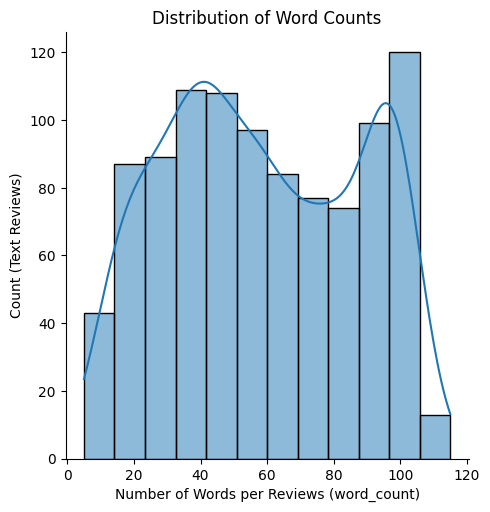

In [36]:
# Plotting the distribution of word counts
sns.displot(x="word_count", data=df.sample(1000), kde=True, fill=True)
plt.ylabel("Count (Text Reviews)")
plt.xlabel("Number of Words per Reviews (word_count)")
plt.title("Distribution of Word Counts")
plt.show()

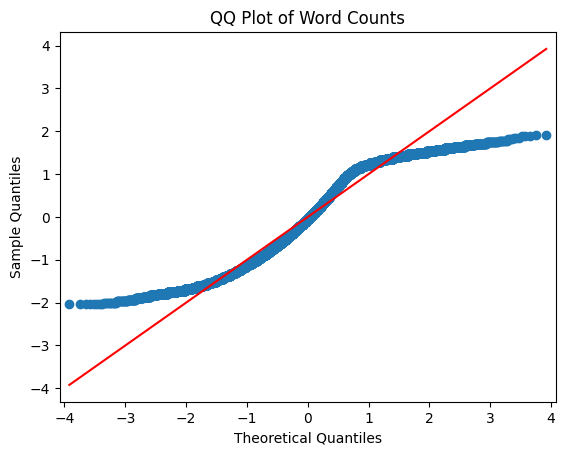

In [37]:
"""QQ Plot"""

from statsmodels.graphics.gofplots import qqplot
from scipy.stats.distributions import norm

qqplot(df["word_count"], line="s", dist=norm, fit=True) # fit=True, to enable Python learn μ and σ from data
plt.title("QQ Plot of Word Counts")
plt.show()

Since the word count distribution is not normal, we will used the non-parametric Mann-Whitney U test to compare the two categories.

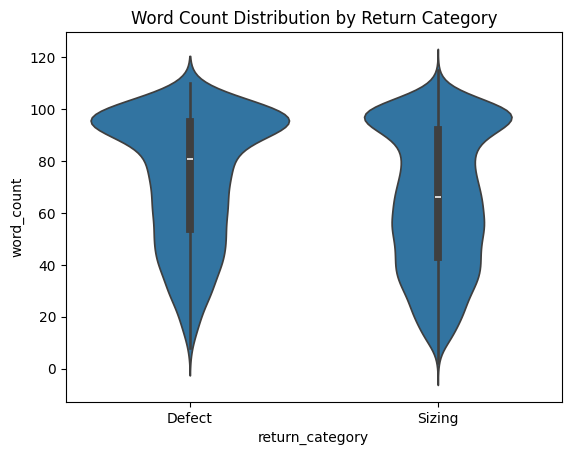

In [38]:
from scipy.stats import mannwhitneyu

defects = df.loc[df["return_category"] == "Defect"]["word_count"]
sizing = df.loc[df["return_category"] == "Sizing"]["word_count"]

returns_cat = df[df["return_category"].isin(["Defect", "Sizing"])]

sns.violinplot(x="return_category", y="word_count", data=returns_cat)

plt.title("Word Count Distribution by Return Category")
plt.show()

In [39]:
u_stat, p_value = mannwhitneyu(defects, sizing, alternative="two-sided")

print(f"Mann Whitney U test p-value: {p_value}")
if p_value < alpha:
    print("Rejecting the Null Hypothesis. Significant difference between the two categories.")
else:
    print("Failing to Reject the Null Hypthesis. No Significant difference between the two categories.")

Mann Whitney U test p-value: 1.0617578031425583e-40
Rejecting the Null Hypothesis. Significant difference between the two categories.


Since there is a **signficant difference** in review lengths between the two categories, we can conclude that the **Angry Rant** hypothesis holds true. Customers tend to write longer reviews when reporting defects compared to sizing issues. This insight can be valuable for understanding customer behavior and tailoring responses accordingly. `word_count` then becomes a feature for our model later!

### Step 2: The **Star Rating** Correlation

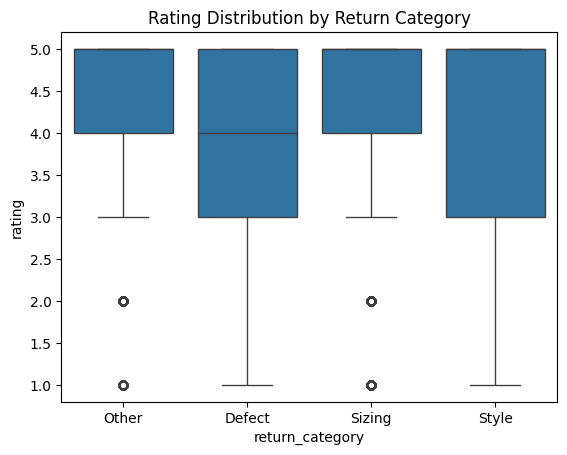


If Rating = 5, it could be anything.
If Rating = 1 or 2, it is highly likely to be a Defect.
This tells us that rating is a weak but valid discriminator.



In [40]:
sns.boxplot(x="return_category", y="rating", data=df)
plt.title("Rating Distribution by Return Category")
plt.show()

print("""
If Rating = 5, it could be anything.
If Rating = 1 or 2, it is highly likely to be a Defect.
This tells us that rating is a weak but valid discriminator.
""")


### Step 3: Text-Nuance (N-Grams)    

Comparing the most common n-grams (bigrams and trigrams) between the two categories can reveal distinct language patterns used by customers when describing defects versus sizing issues.

In [41]:
df.columns

Index(['index_id', 'clothing_id', 'age', 'review_text', 'rating',
       'return_category', 'word_count'],
      dtype='object')

Visualizing Bigrams for Category: Defect


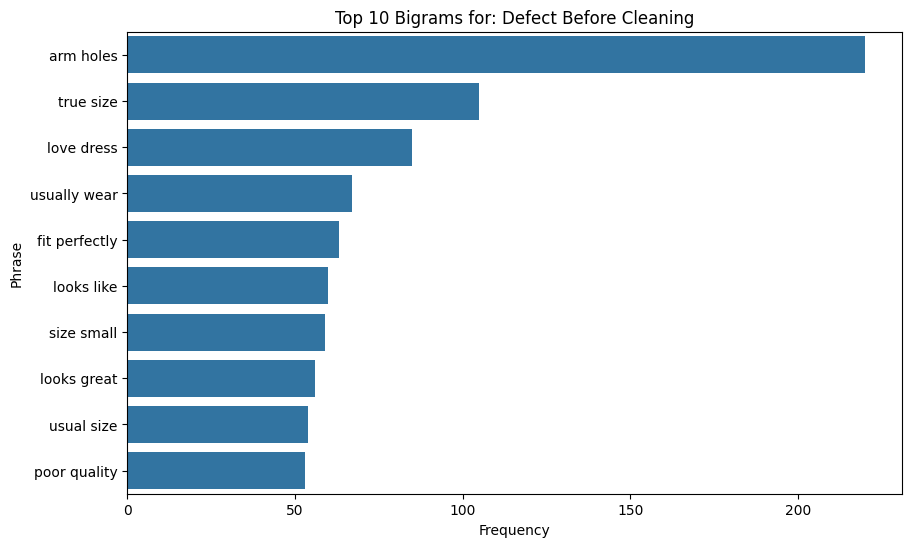

Visualizing Bigrams for Category: Sizing


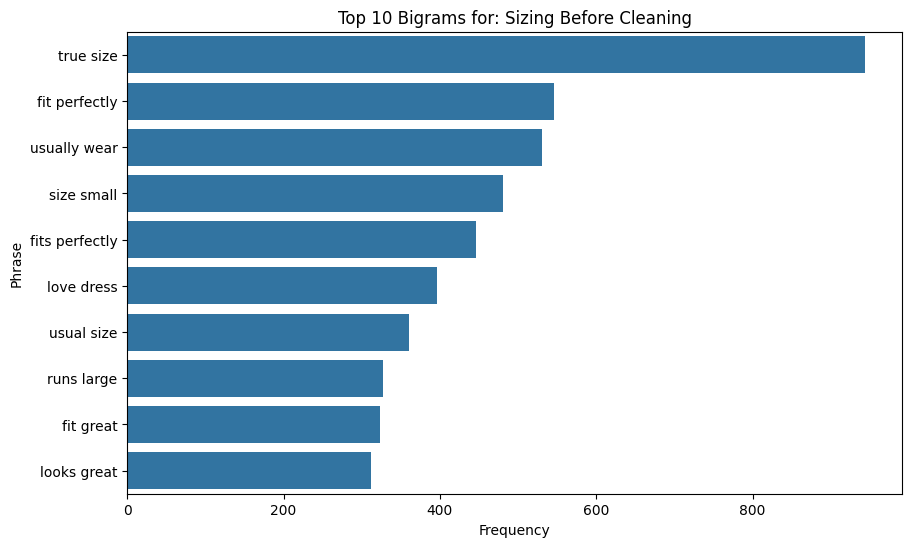

In [42]:
from src.utils import visualize_ngrams

# Looping through categories to compare them side-by-side
# categories = df["return_category"].unique()
categories = ["Defect", "Sizing"]

for cat in categories:
    print(f"Visualizing Bigrams for Category: {cat}")
    visualize_ngrams(df, category_name=cat, ngram_range=(2, 2))

    # print(f"Visualizing Trigrams for Category: {cat}")
    # visualize_ngrams(df, category_name=cat, ngram_range=(3, 3), top_k=10)

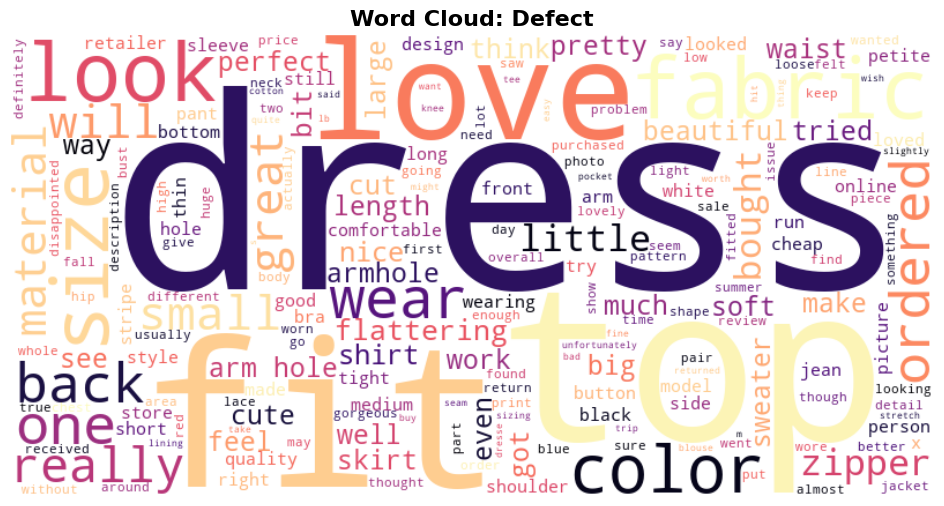

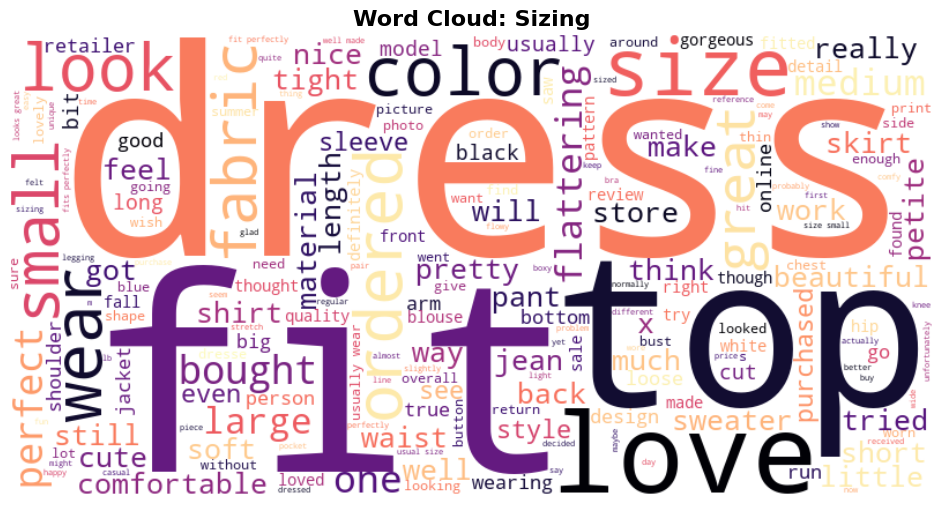

In [43]:
from src.utils import plot_wordcloud


# Executing for "Defect" and "Sizing"
plot_wordcloud(df, "Defect")
plot_wordcloud(df, "Sizing")

### Data Poisoning 

**The classes are heavily overlapping.** `True Size` and `Fit Perfectly` are higly appearing across categories. These labels do not provide much information to the model about the return reason. 

- **Why? Customers leave mixed reviews:** "I love the dress, it fits true to size, but the arm hole ripped."
- **The Model Risk:** If we train on this raw text, the model will see "true size" and have **NO IDEA** if it's `Defect`, `Sizing`, or `Style`. It will guess randomly.

#### Solution: Custom Stop Word Removal (Domain Specific)

We must remove these generic positive phrases from the training data so the model focuses on the differences (e.g., "arm holes" vs "runs large").

1. **Filter out generic phrases:** That do not contribute to distinguishing between return reasons. `e.g.` ["true size", "love dress", "fit perfectly", "looks like", "looks great"].
**NB:** These are good for sentiment analysis, but bad for Root Cause analysis. We don't care if they love it; we care why they returned it.

2. **The Negative Strategy:** Focus on phrases that indicate problems or issues, such as "ripped", "too tight", "color faded", etc. These phrases are more likely to be associated with specific return reasons. 
**NB:** We need to keep phrases like "NOT true to size". `Standard stop-word removal deletes "not"`. We must be careful.

### Exploring Numeric Features

In [44]:
df_num = df.select_dtypes(exclude=["object"])
df_num.columns

Index(['index_id', 'clothing_id', 'age', 'rating', 'word_count'], dtype='object')

In [45]:
display(df_num.head())

,index_id,clothing_id,age,rating,word_count
0,0,767,33,4,8
1,1,1080,34,5,62
2,2,1077,60,3,98
3,3,1049,50,5,22
4,4,847,47,5,36


In [46]:
display(df_num.tail())

,index_id,clothing_id,age,rating,word_count
22636,23481,1104,34,5,28
22637,23482,862,48,3,38
22638,23483,1104,31,3,42
22639,23484,1084,28,3,86
22640,23485,1104,52,5,19


In [47]:
df.dtypes

index_id            int64
clothing_id         int64
age                 int64
review_text        object
rating              int64
return_category    object
word_count          int64
dtype: object

In [48]:
df_num.dtypes

index_id       int64
clothing_id    int64
age            int64
rating         int64
word_count     int64
dtype: object

In [49]:
from src.utils import summarize_df

summarize_df(df_num, "df of numeric features")

===== DataFrame (DF OF NUMERIC FEATURES) Summary =====
===== DataFrame Index =====


RangeIndex(start=0, stop=22641, step=1)

===== DataFrame Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22641 entries, 0 to 22640
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   index_id     22641 non-null  int64
 1   clothing_id  22641 non-null  int64
 2   age          22641 non-null  int64
 3   rating       22641 non-null  int64
 4   word_count   22641 non-null  int64
dtypes: int64(5)
memory usage: 884.5 KB

===== DataFrame Description =====


,index_id,clothing_id,age,rating,word_count
count,22641.000000,22641.000000,22641.000000,22641.000000,22641.000000
mean,11740.849035,919.332362,43.280376,4.183561,60.196679
std,6781.957509,202.266874,12.326980,1.115762,28.534612
min,0.000000,1.000000,18.000000,1.000000,2.000000
25%,5872.000000,861.000000,34.000000,4.000000,36.000000
50%,11733.000000,936.000000,41.000000,5.000000,59.000000
75%,17621.000000,1078.000000,52.000000,5.000000,88.000000
max,23485.000000,1205.000000,99.000000,5.000000,115.000000



===== Duplicate Rows =====
No duplicate rows found.

===== Missing Values per Column =====
index_id       0
clothing_id    0
age            0
rating         0
word_count     0
dtype: int64


In [50]:
df["word_count"].describe()

count    22641.000000
mean        60.196679
std         28.534612
min          2.000000
25%         36.000000
50%         59.000000
75%         88.000000
max        115.000000
Name: word_count, dtype: float64

### Studying the relationship between Age and Return Reasons

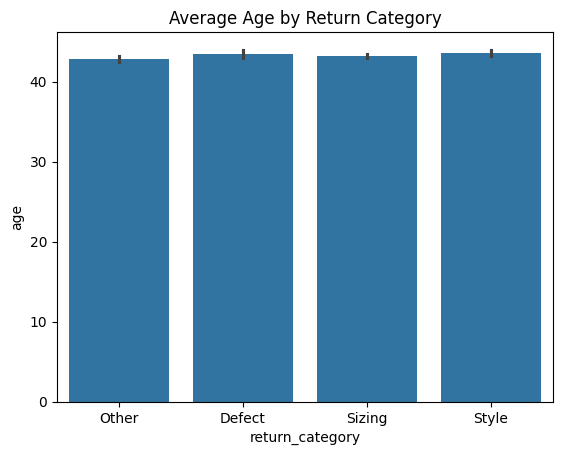

,avg_age
return_category,
Defect,43.46
Other,42.86
Sizing,43.23
Style,43.58


In [51]:
sns.barplot(x="return_category", y="age", data=df)
plt.title("Average Age by Return Category")
plt.show()

grouped_age = np.round(df.groupby("return_category")["age"].agg(avg_age="mean"), 2)
display(grouped_age)

In [52]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
df["age_group"].value_counts()

age_group
35-44    7093
25-34    5493
45-54    4747
55-64    2984
18-24    1183
65+      1137
<18         4
Name: count, dtype: int64

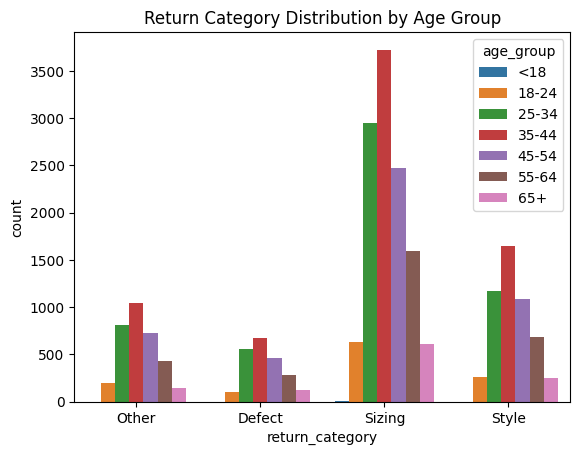

In [53]:
sns.countplot(x="return_category", hue="age_group", data=df)
plt.title("Return Category Distribution by Age Group")
plt.show()

### Visualzing the Distribution of age, rating and word_count

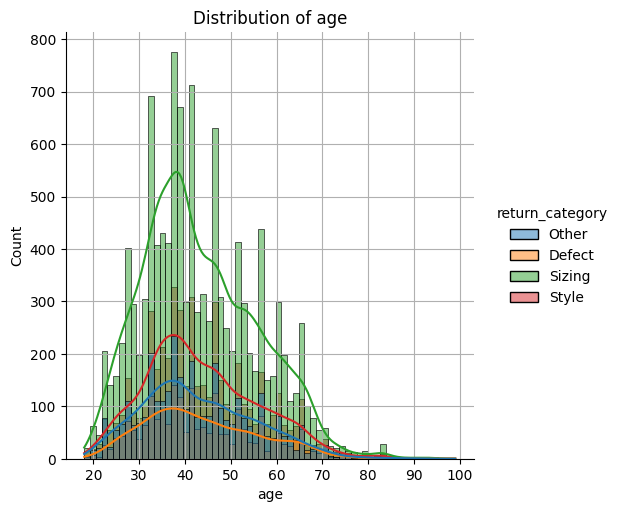

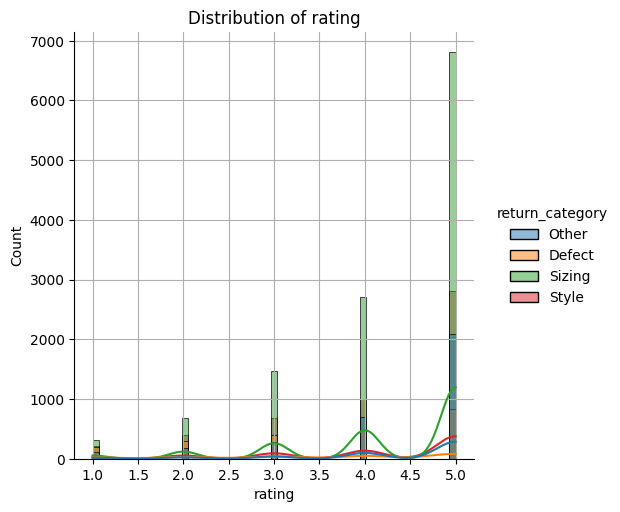

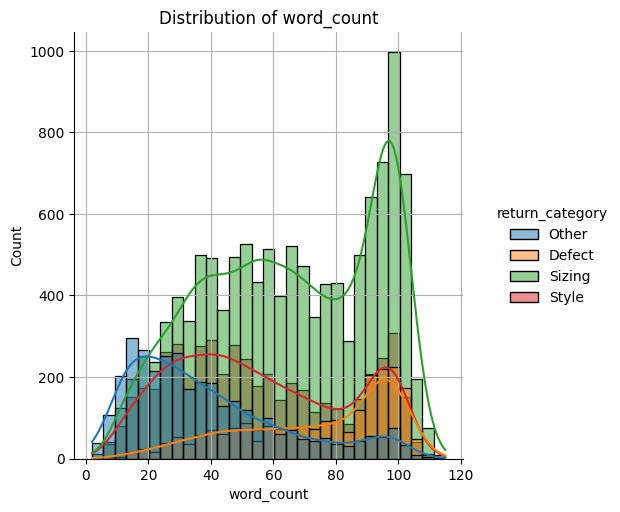

In [54]:
cats = ["age", "rating", "word_count"]
for cat in cats:
    sns.displot(x=cat, data=df, kde=True, fill=True, hue="return_category")
    plt.title(f"Distribution of {cat}")
    plt.grid(True)
    plt.show()

### Saving the Analyzed Data with 1 new feature 'word_count' for future modeling steps

In [55]:
df.dtypes

index_id              int64
clothing_id           int64
age                   int64
review_text          object
rating                int64
return_category      object
word_count            int64
age_group          category
dtype: object

In [56]:
output_path = "../data/interim/labeled2_reviews.csv"
df.to_csv(output_path, index=False)

print(f"Data successfully saved to {output_path}")

Data successfully saved to ../data/interim/labeled2_reviews.csv
